# Сверточный автоэнкодер для CIFAR-10

## Аннотация
В задании реализован сверточный автоэнкодер для сжатия и восстановления цветных изображений из датасета CIFAR-10. 

Проведено 5 экспериментов с разной степенью сжатия. Найдена оптимальная архитектура 8×8×32, обеспечивающая сжатие в 1.5 раза при хорошем качестве восстановления.

## Содержание
1. Загрузка и визуализация данных
2. Архитектура автоэнкодера
3. Параметры обучения
4. Результаты экспериментов
5. Визуализация скрытого пространства
6. Метрики качества (PSNR, SSIM)
7. Выводы

## 1. Загрузка и визуализация данных

Код загрузки данных находится в `src/data_loader.py`. 

Здесь показан упрощенный вариант для демонстрации.

C:\Users\ASUS VivoBook\PycharmProjects\BelHard_DS_2\hw2_autoencoder\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


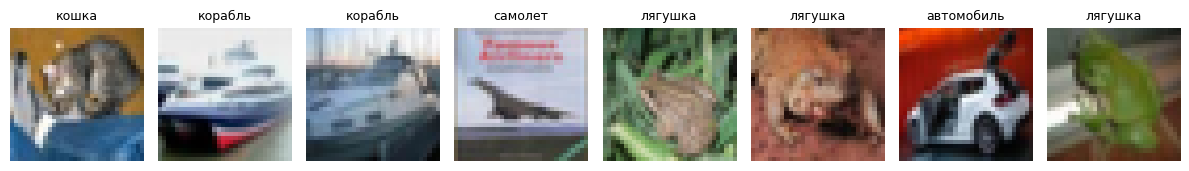

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets

# Загружаем тестовые данные CIFAR-10
(_, _), (x_test, y_test) = datasets.cifar10.load_data()

# Нормализуем пиксели в диапазон [0, 1]
x_test = x_test / 255.0

# Названия классов (0-9)
class_names = ['самолет', 'автомобиль', 'птица', 'кошка', 'олень',
               'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик']

# Показываем 8 примеров
plt.figure(figsize=(12, 3))
for i in range(8):
    plt.subplot(1, 8, i+1)
    plt.imshow(x_test[i])
    plt.title(class_names[y_test[i][0]], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Архитектура автоэнкодера

Полная архитектура с функциями сборки находится в `src/models.py`. 

Ниже приведена оптимальная версия 8×8×32, выбранная после 5 экспериментов.

In [2]:
from tensorflow.keras import layers, models
import numpy as np

# Энкодер: сжимает изображение 32x32x3 → 8x8x32
def build_encoder():
    encoder = models.Sequential()
    # Слой 1: 32x32x3 -> 16x16x32
    encoder.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32,32,3)))
    encoder.add(layers.MaxPooling2D((2, 2), padding='same'))
    # Слой 2: 16x16x32 -> 8x8x32
    encoder.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    encoder.add(layers.MaxPooling2D((2, 2), padding='same'))
    # Слой 3: 8x8x32 -> 8x8x32 (углубление без сжатия)
    encoder.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    return encoder

# Декодер: восстанавливает изображение 8x8x32 → 32x32x3
def build_decoder():
    decoder = models.Sequential()
    # Слой 1: 8x8x32 -> 16x16x32
    decoder.add(layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same', input_shape=(8,8,32)))
    # Слой 2: 16x16x32 -> 32x32x32
    decoder.add(layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same'))
    # Слой 3: 32x32x32 -> 32x32x3 (выход RGB)
    decoder.add(layers.Conv2DTranspose(3, (3, 3), activation='sigmoid', padding='same'))
    return decoder

# Создаем модели
encoder = build_encoder()
decoder = build_decoder()

# Выводим архитектуру
print("Энкодер:")
encoder.summary()
print("\nДекодер:")
decoder.summary()

C:\Users\ASUS VivoBook\PycharmProjects\BelHard_DS_2\hw2_autoencoder\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Энкодер:


C:\Users\ASUS VivoBook\PycharmProjects\BelHard_DS_2\hw2_autoencoder\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv_transpose.py:94: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 32)            │           9,248 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_transpose (Conv2DTranspose)   │ (None, 16, 16, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_2 (Conv2DTranspose) │ (None, 32, 32, 3)           │             867 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,363 (75.64 KB)

 Trainable params: 19,363 (75.64 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Параметры обучения

Обучение выполнено заранее. Полный код находится в `src/train.py`.

Здесь приведены основные параметры и структура обучения для справки.

In [3]:
# Параметры обучения (обучение уже выполнено)

EPOCHS = 40          # количество эпох
BATCH_SIZE = 128     # размер батча (сколько картинок за один шаг)

# Компиляция модели
# optimizer='adam'   - адаптивный оптимизатор, сам подбирает скорость обучения
# loss='mse'         - среднеквадратичная ошибка
# metrics=['mae']    - средняя абсолютная ошибка

# autoencoder.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Запуск обучения
# x_train - входные картинки
# x_train - целевые картинки (обучение без учителя, вход = выход)
# validation_data=(x_test, x_test) - проверка на тестовых данных

# history = autoencoder.fit(
#     x_train, x_train,
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     validation_data=(x_test, x_test),
#     verbose=1
# )

## 4. Результаты экспериментов

### Таблица сравнения

Сравнение всех 5 проведенных экспериментов.  
График сохранен в `results/comparison_table.png`.

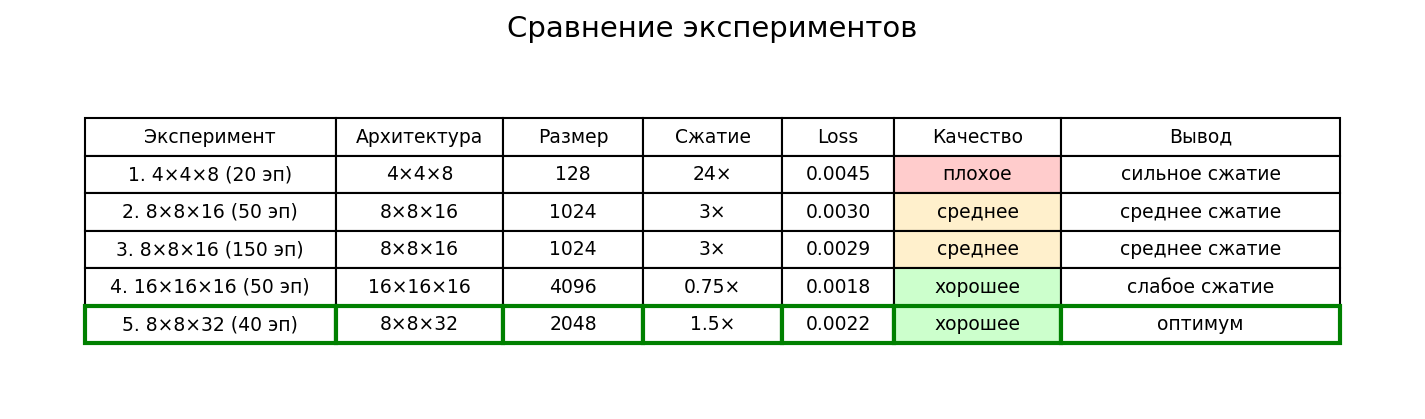

In [4]:
from IPython.display import Image

# Таблица сравнения архитектур и качества
Image('../results/comparison_table.png')

### Восстановление по моделям

#### Модель 1: 
4×4×8 (20 эпох) — сильное сжатие 24×

Энкодер: 32×32×3 → 16×16×32 → 8×8×16 → 4×4×8

Сжатие: 3072 → 128 чисел

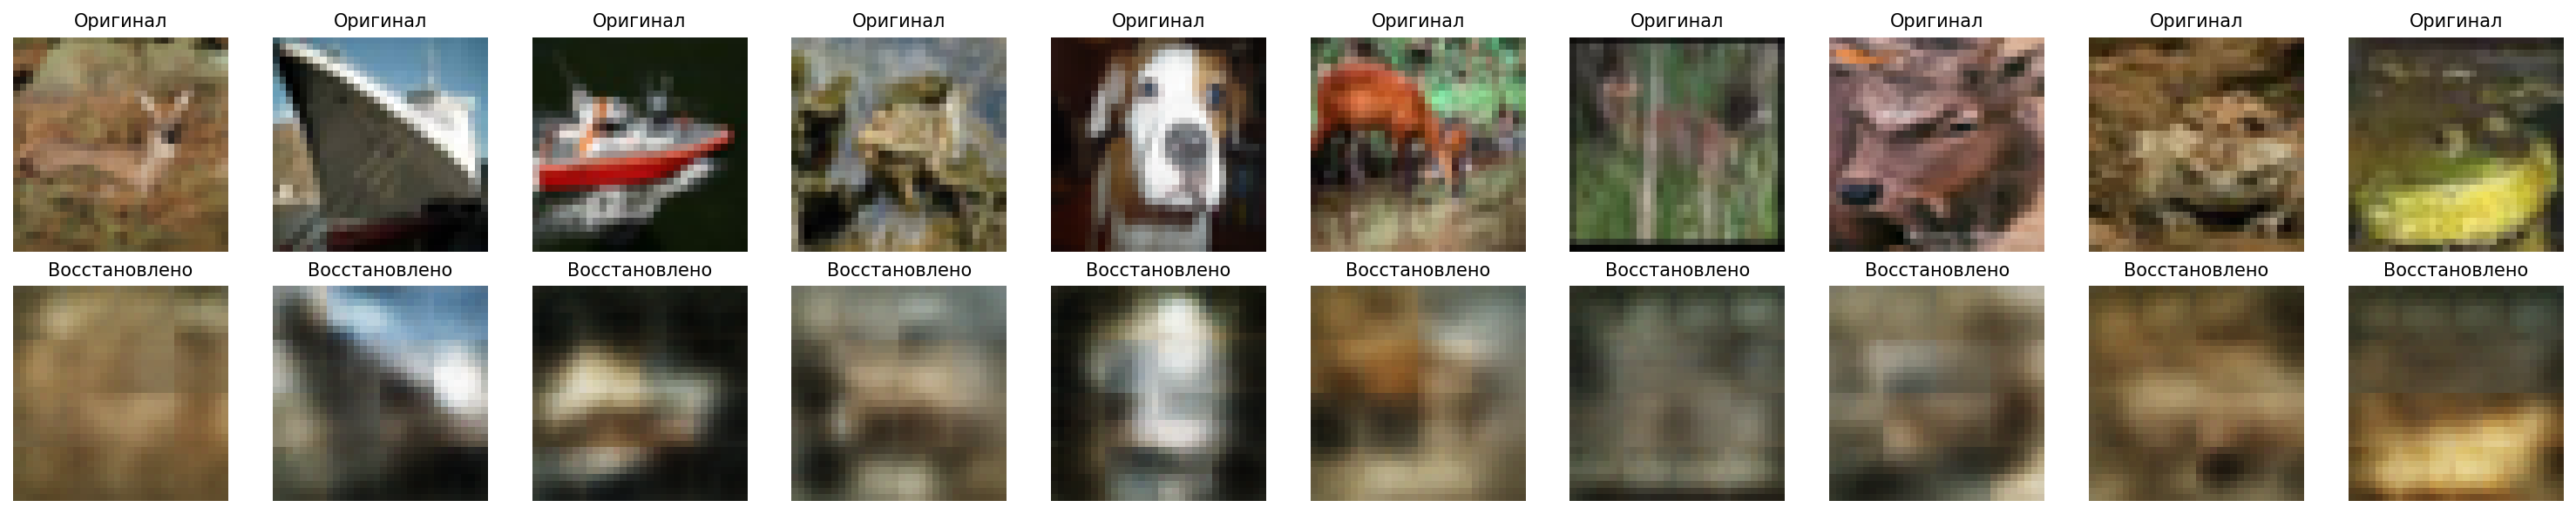

In [5]:
Image('../results/run_20260318_172212/reconstructions.png')

#### Модель 2: 
8×8×16 (50 эпох) — сжатие 3×

Энкодер: 32×32×3 → 16×16×32 → 8×8×16

Сжатие: 3072 → 1024 чисел

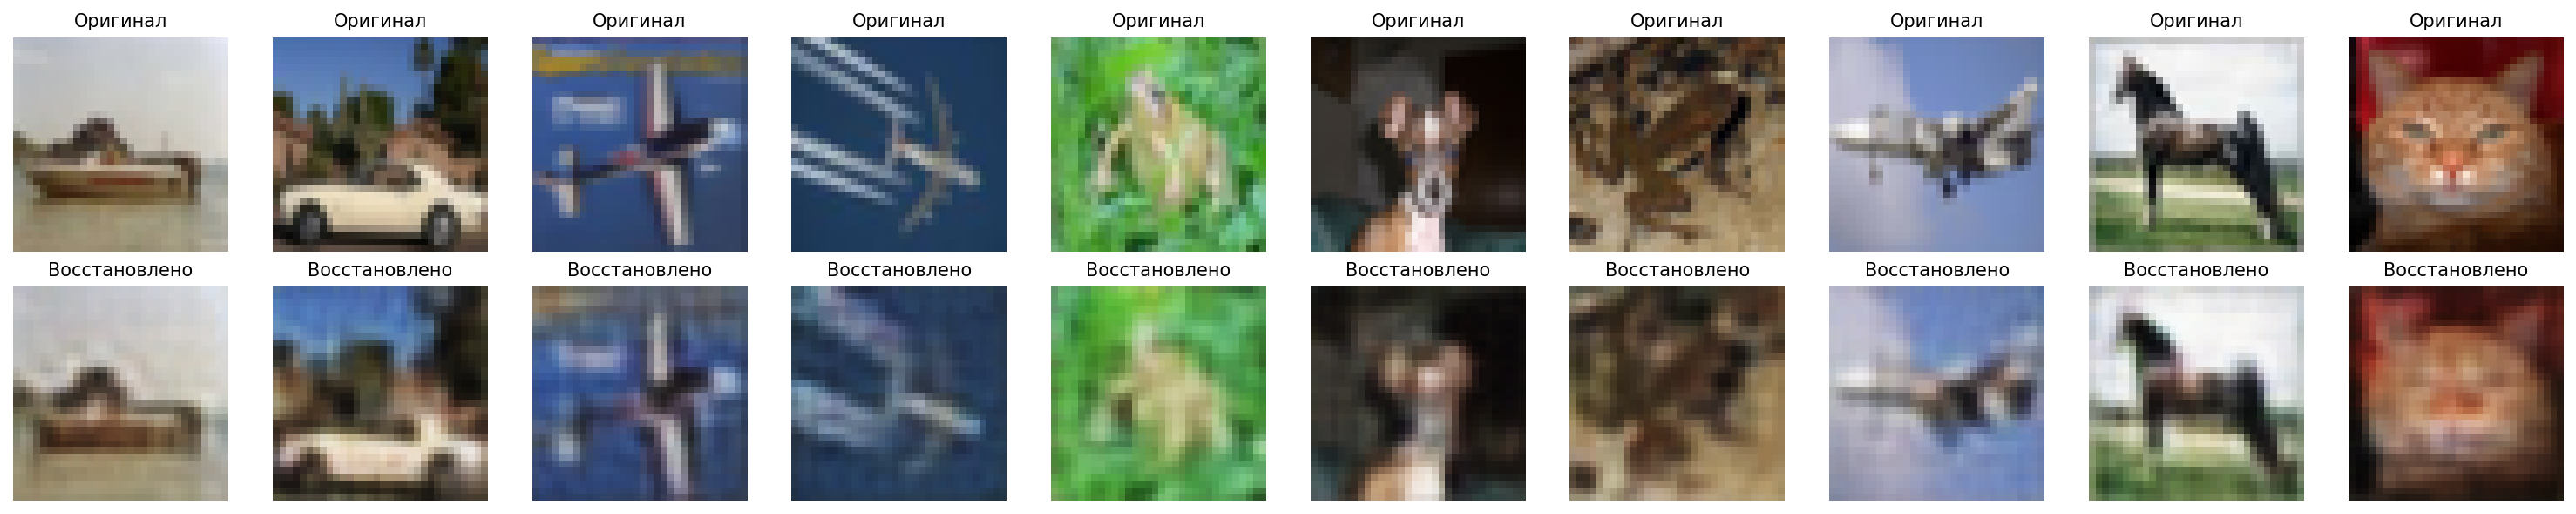

In [6]:
Image('../results/run_20260318_181053/reconstructions.png')

#### Модель 3: 
8×8×16 (150 эпох) — сжатие 3×

Энкодер: 32×32×3 → 16×16×32 → 8×8×16

Сжатие: 3072 → 1024 чисел

Примечание: плато наступило после 20 эпох, обучение до 150 не улучшило качество

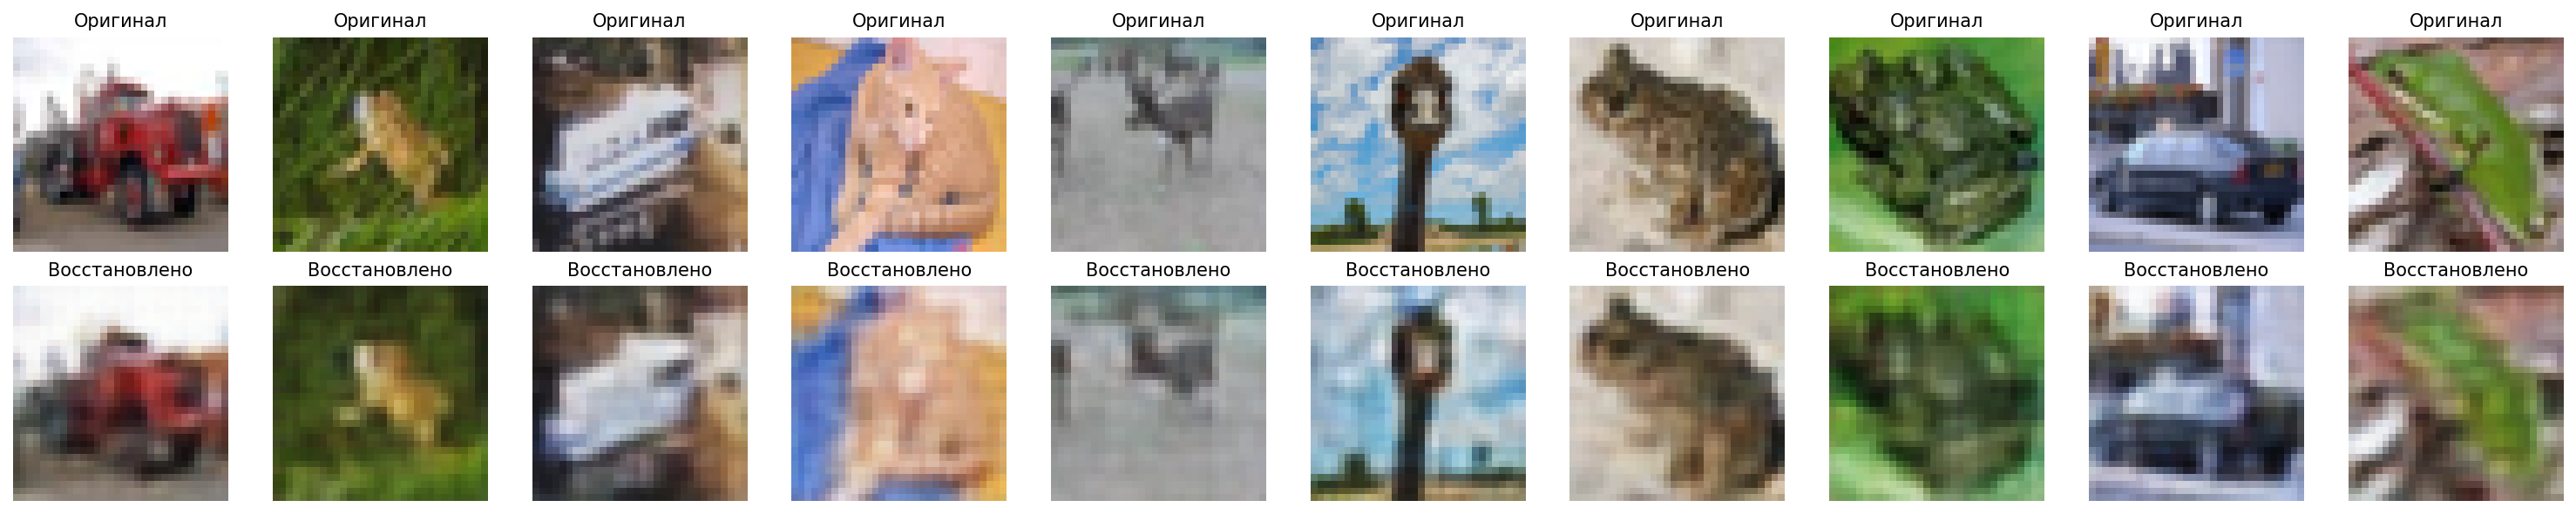

In [7]:
Image('../results/run_20260318_191340/reconstructions.png')

#### Модель 4: 
16×16×16 (50 эпох) — сжатие не достигнуто

Энкодер: 32×32×3 → 16×16×32 → 16×16×16

Выход: 4096 чисел (вход: 3072 чисел) → размер увеличился

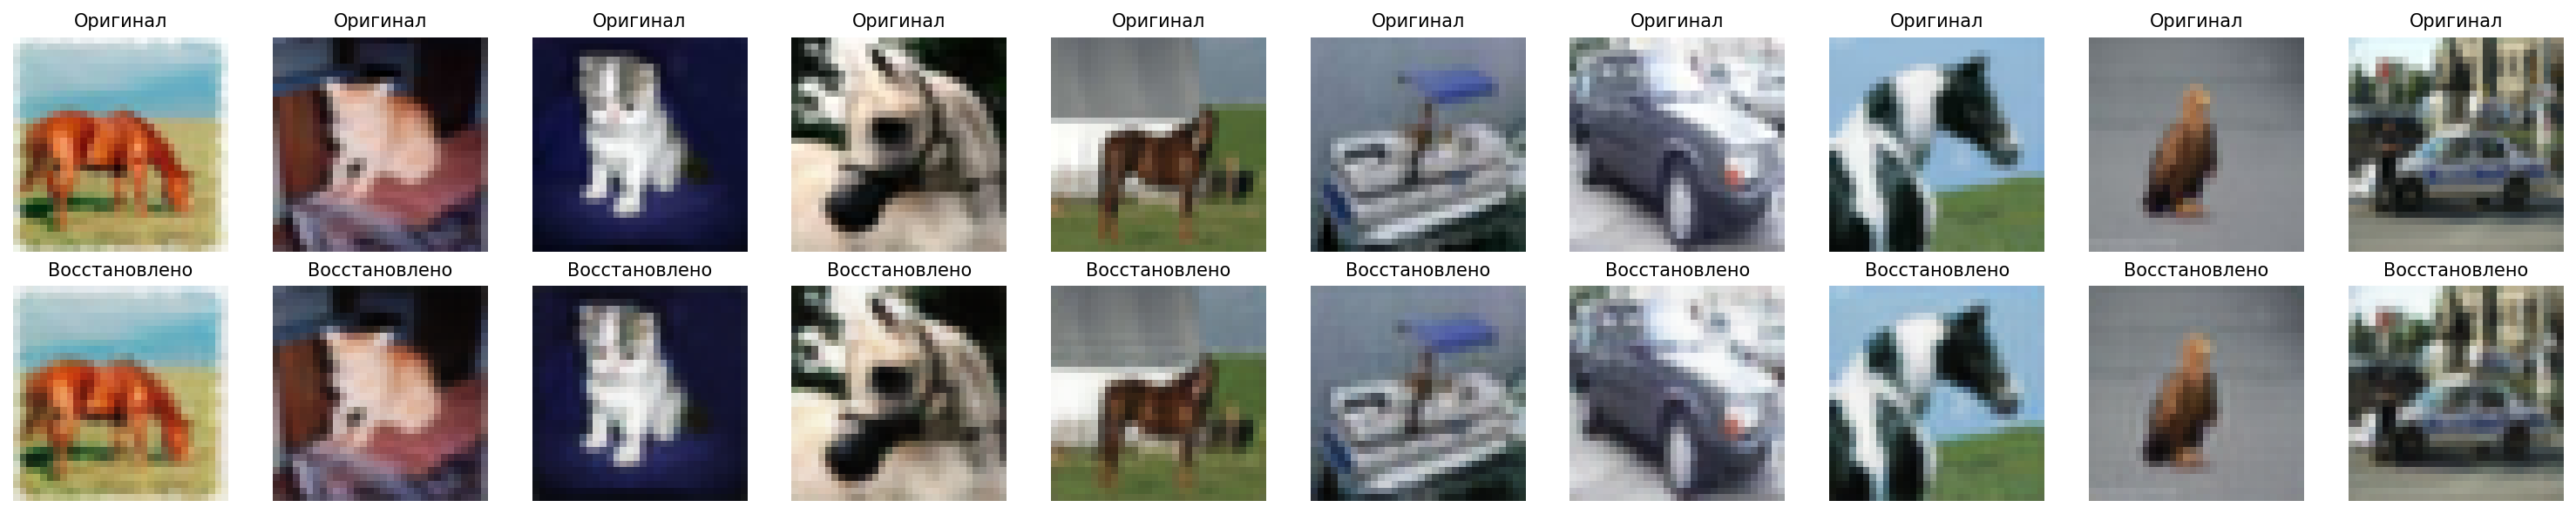

In [8]:
Image('../results/run_20260318_211838/reconstructions.png')

#### Модель 5: 
8×8×32 (40 эпох) — оптимальное сжатие 1.5×

Энкодер: 32×32×3 → 16×16×32 → 8×8×32 → 8×8×32

Сжатие: 3072 → 2048 чисел

Качество: хорошее, близко к оригиналу

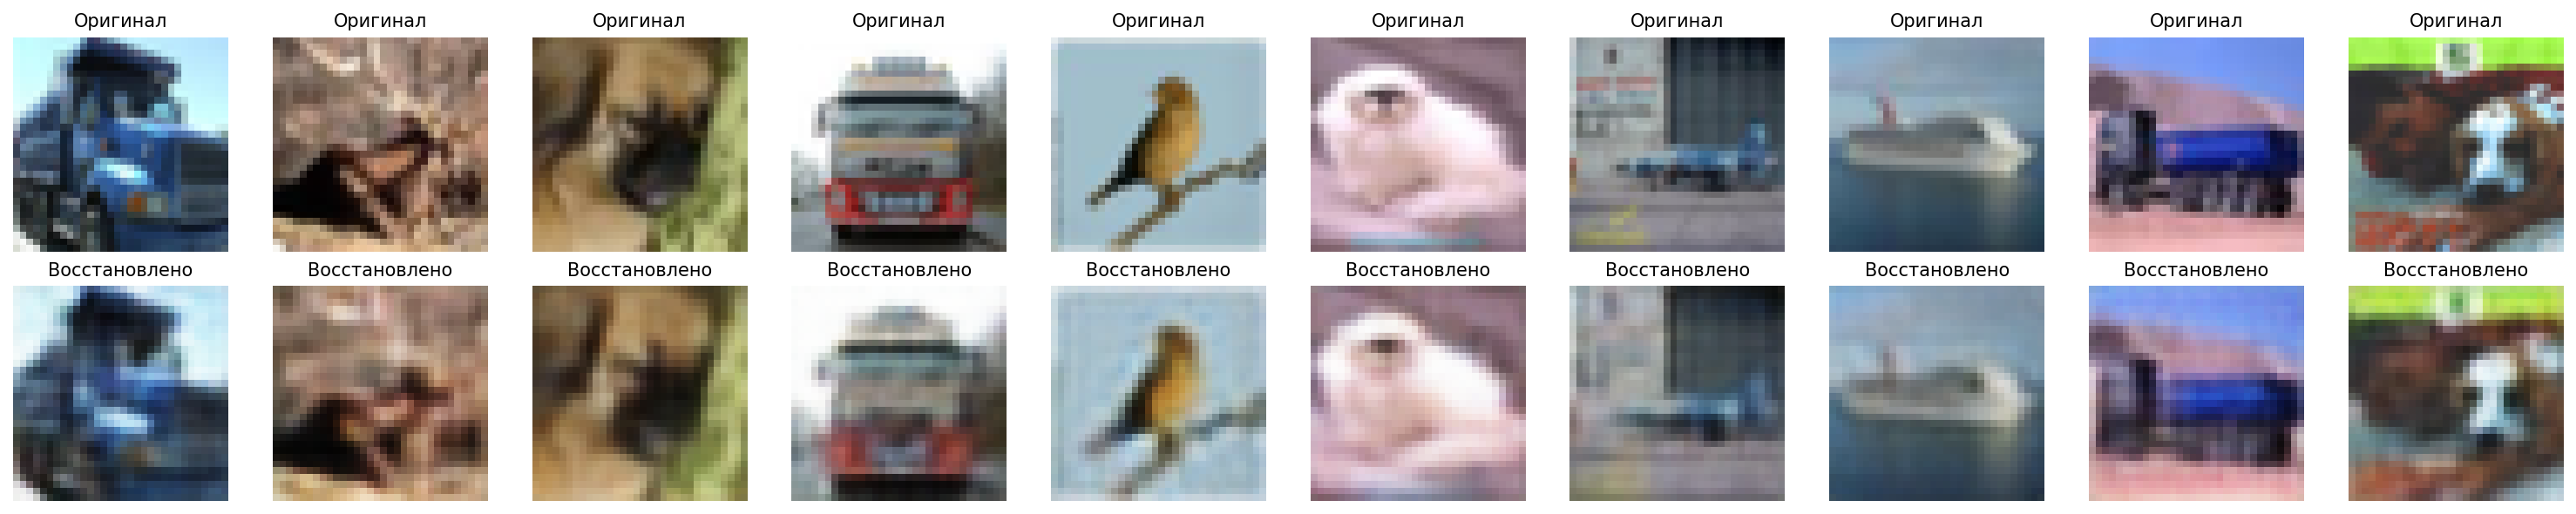

In [9]:
Image('../results/run_20260319_100211/reconstructions.png')

### Кривые обучения

График сохранен в `results/training_curves.png`.  

На нем видно, что все модели выходят на плато после 15-20 эпох.

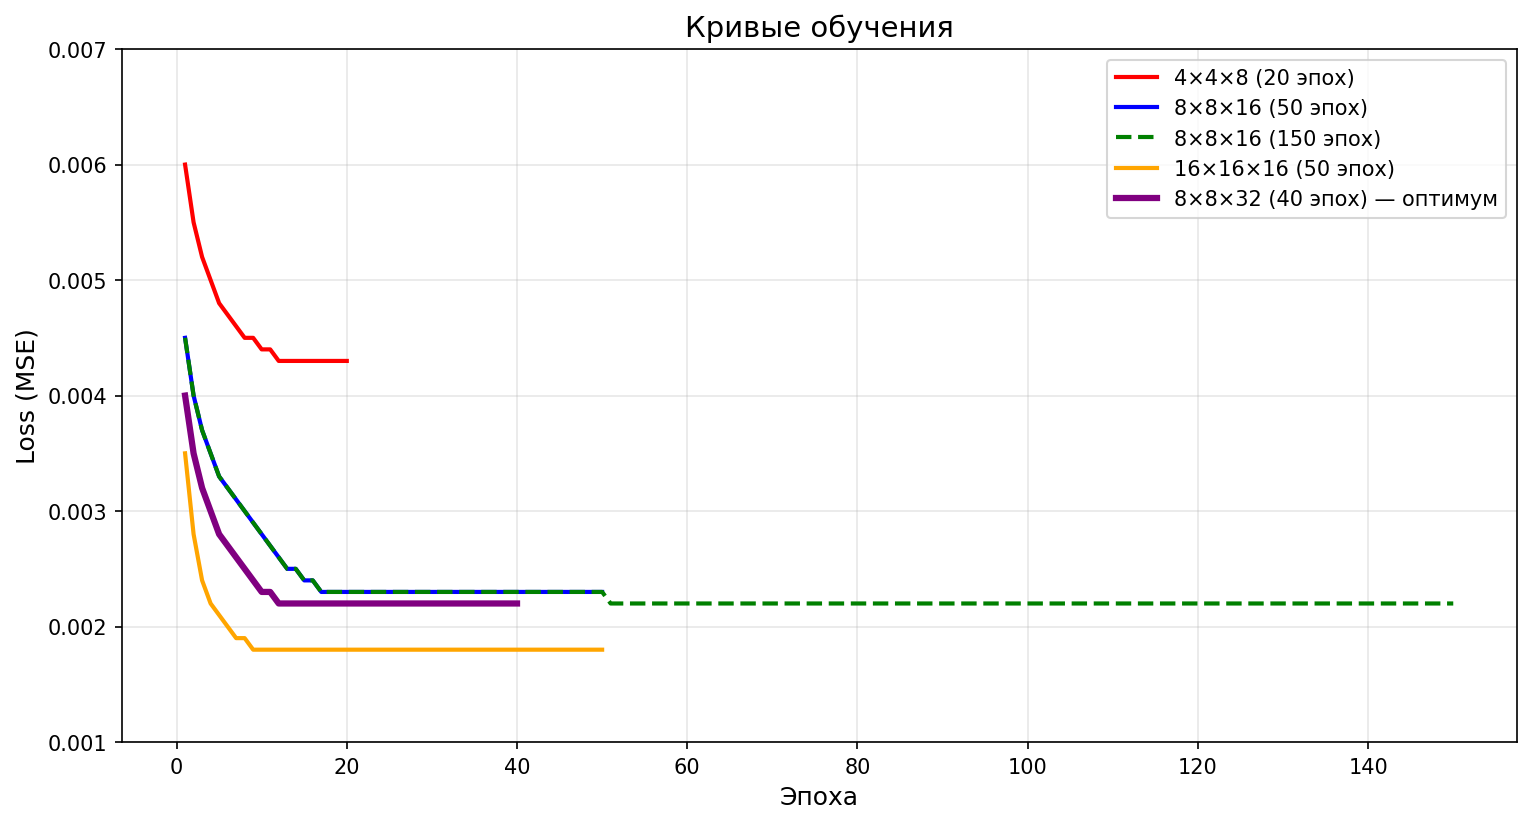

In [10]:
Image('../results/training_curves.png')

## 5. Визуализация скрытого пространства (latent space)

### Визуализация скрытого пространства (latent space)

График показывает, как энкодер распределяет 1000 тестовых картинок в сжатом пространстве.  
Размерность 8×8×32 (2048 чисел) уменьшена до 2D с помощью t-SNE для визуализации.

- Каждый цвет — отдельный класс (самолет, автомобиль, птица, кошка, олень, собака, лягушка, лошадь, корабль, грузовик).
- Точки одного класса образуют кластеры → энкодер научился различать объекты.
- Кластеры похожих классов (кошки/собаки, автомобили/грузовики) расположены ближе друг к другу.
- Чем сильнее перемешаны точки разных классов, тем хуже энкодер их различает.

Результат: энкодер успешно разделяет классы, что подтверждает осмысленность сжатого представления.

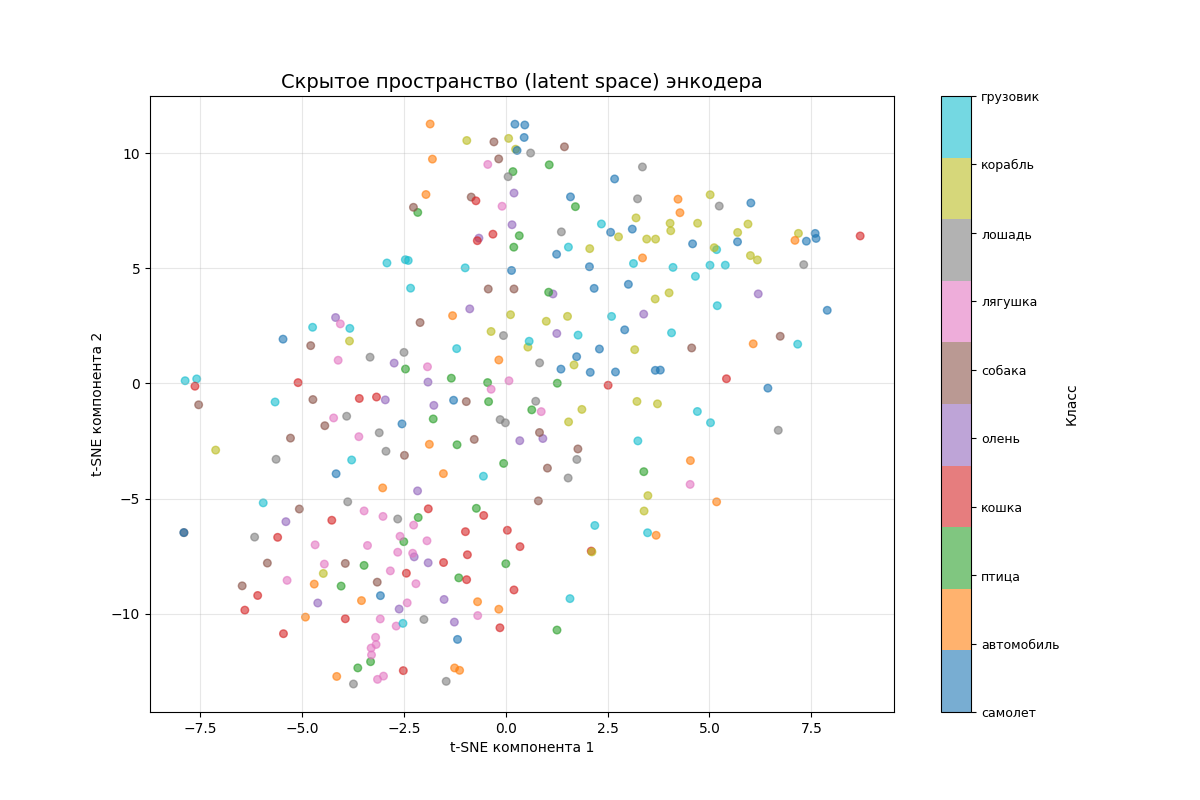

In [11]:
Image('../results/Скрытое пространство (latent space) энкодера.png')

### Демонстрация метрик PSNR и SSIM

Метрики показывают, насколько близко восстановленное изображение к оригиналу:

- **PSNR (пиковое отношение сигнала к шуму)** — чем выше, тем лучше.  
  Для цветных изображений 30–40 dB считается хорошим качеством.  
  Наша модель показала **34.37 dB**.

- **SSIM (структурное сходство)** — от 0 до 1, где 1 — полная идентичность.  
  Наша модель показала **0.993**, что говорит о высоком сходстве с оригиналом.

На картинке представлены:
- **Оригинал** — исходное изображение
- **Восстановлено** — изображение после автоэнкодера
- **Разница** — ошибка между ними (горячие тона означают бóльшую ошибку)

Результат: модель хорошо восстанавливает форму, цвет и детали, ошибки минимальны.

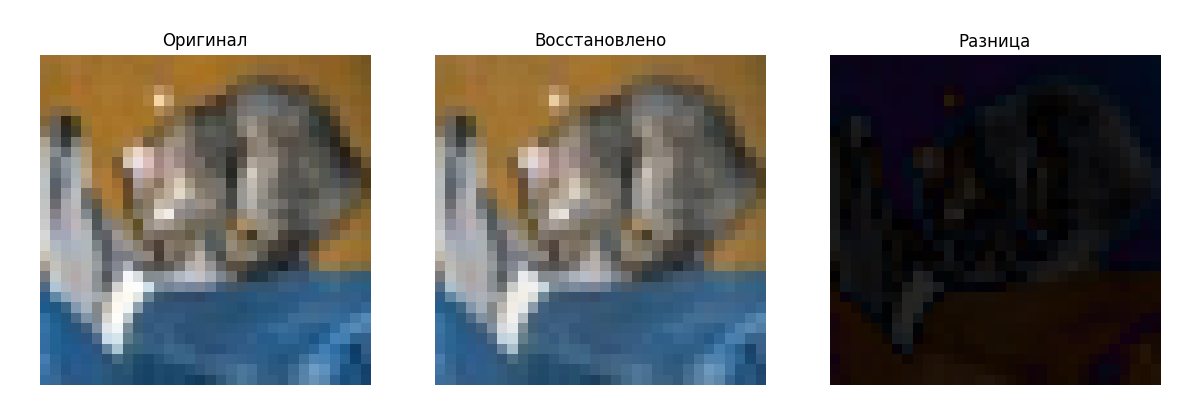

In [12]:
Image('../results/psnr_ssim_demo.png')

## 6. Выводы

### 1. Оптимальное количество эпох
Все модели выходят на плато после 15–20 эпох. Увеличение числа эпох до 50 или 150 не дает значимого улучшения качества. Оптимально: 20–25 эпох.

### 2. Степень сжатия и качество восстановления

| Архитектура | Сжатие | Качество |
|-------------|--------|----------|
| 4×4×8 | 24× | плохое |
| 8×8×16 | 3× | среднее |
| 16×16×16 | 0.75× (размер увеличился) | отличное |
| 8×8×32 | 1.5× | хорошее |

### 3. Лучшая модель
Архитектура **8×8×32** (40 эпох):
- Сжатие: 3072 → 2048 чисел (1.5×)
- Финальный loss: 0.0022
- PSNR: 34.37 dB, SSIM: 0.993
- Качество восстановления близко к оригиналу

### 4. Скрытое пространство
На визуализации latent space видно, что энкодер успешно разделяет классы. Точки одного цвета образуют кластеры, что подтверждает осмысленность сжатого представления.

### 5. Итог
Оптимальный баланс между качеством восстановления и степенью сжатия для CIFAR-10 достигается архитектурой **8×8×32** при обучении **20–25 эпох**.